# Step 2 - Exploratory Data Analysis

Demand patterns by site, cement type and period. Weather correlation. Planned-vs-actual censoring analysis.

In [5]:
import sys
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

# Add the src folder to Python's search path
sys.path.append(str(PROJECT_ROOT / "src"))

print("Project Root:", PROJECT_ROOT)

Project Root: c:\Users\Olami\OneDrive\Documents\DATASCIENCEPROJECT\MIG_Cement_Demand_Forecasting


## 2 - Import libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mig_cement.config import settings
from mig_cement.data import load

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

print("Imports successful!")

Imports successful!


## 3  Load the cleaned dataset

In [7]:
panel = pd.read_parquet(settings.interim_dir / "operations_clean.parquet")

print(f"Dataset Shape: {panel.shape}")

panel.head()

Dataset Shape: (32880, 22)


,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity,region,behavior,received_tonnes,rejected_delivery_tonnes,served_tonnes,induced_shortfall,was_constrained,unmet_tonnes,silo_utilisation,cover_days,y
0,2022-01-01,SITE_001,CEM_II,43.18,34.54,52.56,45.83,63.85,3.40,-3.10,448,North,aggressive,45.83,0.0,34.54,0,1,8.64,0.142522,1.521714,34.54
1,2022-01-02,SITE_001,CEM_I,45.26,45.26,63.85,19.97,38.56,3.23,14.28,448,North,aggressive,19.97,0.0,45.26,0,0,0.00,0.086071,1.410738,45.26
2,2022-01-03,SITE_001,CEM_III,38.69,38.69,38.56,47.19,47.06,2.64,6.40,448,North,aggressive,47.19,0.0,38.69,0,0,0.00,0.105045,0.996640,38.69
3,2022-01-04,SITE_001,CEM_I,33.16,33.16,47.06,18.74,32.64,8.25,14.23,448,North,aggressive,18.74,0.0,33.16,0,0,0.00,0.072857,1.419180,33.16
4,2022-01-05,SITE_001,CEM_III,56.88,47.04,32.64,14.40,0.00,2.69,8.97,448,North,aggressive,14.40,0.0,47.04,0,1,9.84,0.000000,0.693878,47.04


## INITIAL DATA ASSESMENT 

In [8]:

# ==========================================

# Ensure the date column is in datetime format
panel["date"] = pd.to_datetime(panel["date"])

summary = {
    "Rows": len(panel),
    "Columns": panel.shape[1],
    "Date Range": f"{panel['date'].min().date()} to {panel['date'].max().date()}",
    "Sites": panel["site_id"].nunique(),
    "Regions": panel["region"].nunique(),
    "Cement Types": panel["cement_type"].nunique(),
    "Missing Values": int(panel.isna().sum().sum()),
    "Duplicate Rows": int(panel.duplicated().sum())
}

display(
    pd.DataFrame.from_dict(summary, orient="index", columns=["Value"])
)

,Value
Rows,32880
Columns,22
Date Range,2022-01-01 to 2024-12-31
Sites,30
Regions,4
Cement Types,3
Missing Values,4003
Duplicate Rows,0


## Exploratory Data Analysis

## Descriptive statistics

In [9]:
summary_stats = (
    panel[ [
            "planned_pour_tonnes",
            "consumed_tonnes",
            "opening_inventory_tonnes",
            "deliveries_tonnes",
            "closing_inventory_tonnes",
            "rain_mm",
            "avg_temp_c" ]]
    .describe()
    .T
    .round(2))

display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
planned_pour_tonnes,32880.0,30.70,19.49,0.0,12.83,33.46,47.61,69.98
consumed_tonnes,32880.0,23.72,16.85,0.0,10.71,19.72,36.49,69.97
opening_inventory_tonnes,32880.0,123.61,150.58,0.0,0.47,44.85,256.08,487.00
deliveries_tonnes,32880.0,29.29,12.33,0.0,19.30,29.49,39.75,50.00
closing_inventory_tonnes,32880.0,123.68,150.63,0.0,0.44,44.83,256.16,487.00
rain_mm,32880.0,5.01,5.00,0.0,1.44,3.47,6.97,50.00
avg_temp_c,32880.0,10.09,8.52,-5.0,3.34,9.99,16.70,35.00


Descriptive statistics were generated to summarise the numerical variables and understand their overall characteristics. The results show considerable variation in cement consumption, inventory levels, and weather conditions across the dataset.

In [10]:
panel.groupby("site_id")["opening_inventory_tonnes"].mean().sort_values(ascending=False)

site_id
SITE_004    456.063458
SITE_019    449.806323
SITE_029    421.786478
SITE_009    338.213257
SITE_027    300.591807
SITE_002    274.083923
SITE_012    261.454024
SITE_028    151.593978
SITE_023    140.509982
SITE_016    135.117007
SITE_026    134.035109
SITE_024    122.925210
SITE_015    108.318695
SITE_006     88.707819
SITE_014     82.526524
SITE_013     53.566122
SITE_003     17.127847
SITE_030     16.129562
SITE_017     14.667646
SITE_001     14.180739
SITE_018     13.980219
SITE_022     13.382746
SITE_010     13.244288
SITE_025     13.217801
SITE_007     13.081031
SITE_011     12.377628
SITE_005     12.333440
SITE_008     12.248750
SITE_021     11.604005
SITE_020     11.439297
Name: opening_inventory_tonnes, dtype: float64

## Numerical Features

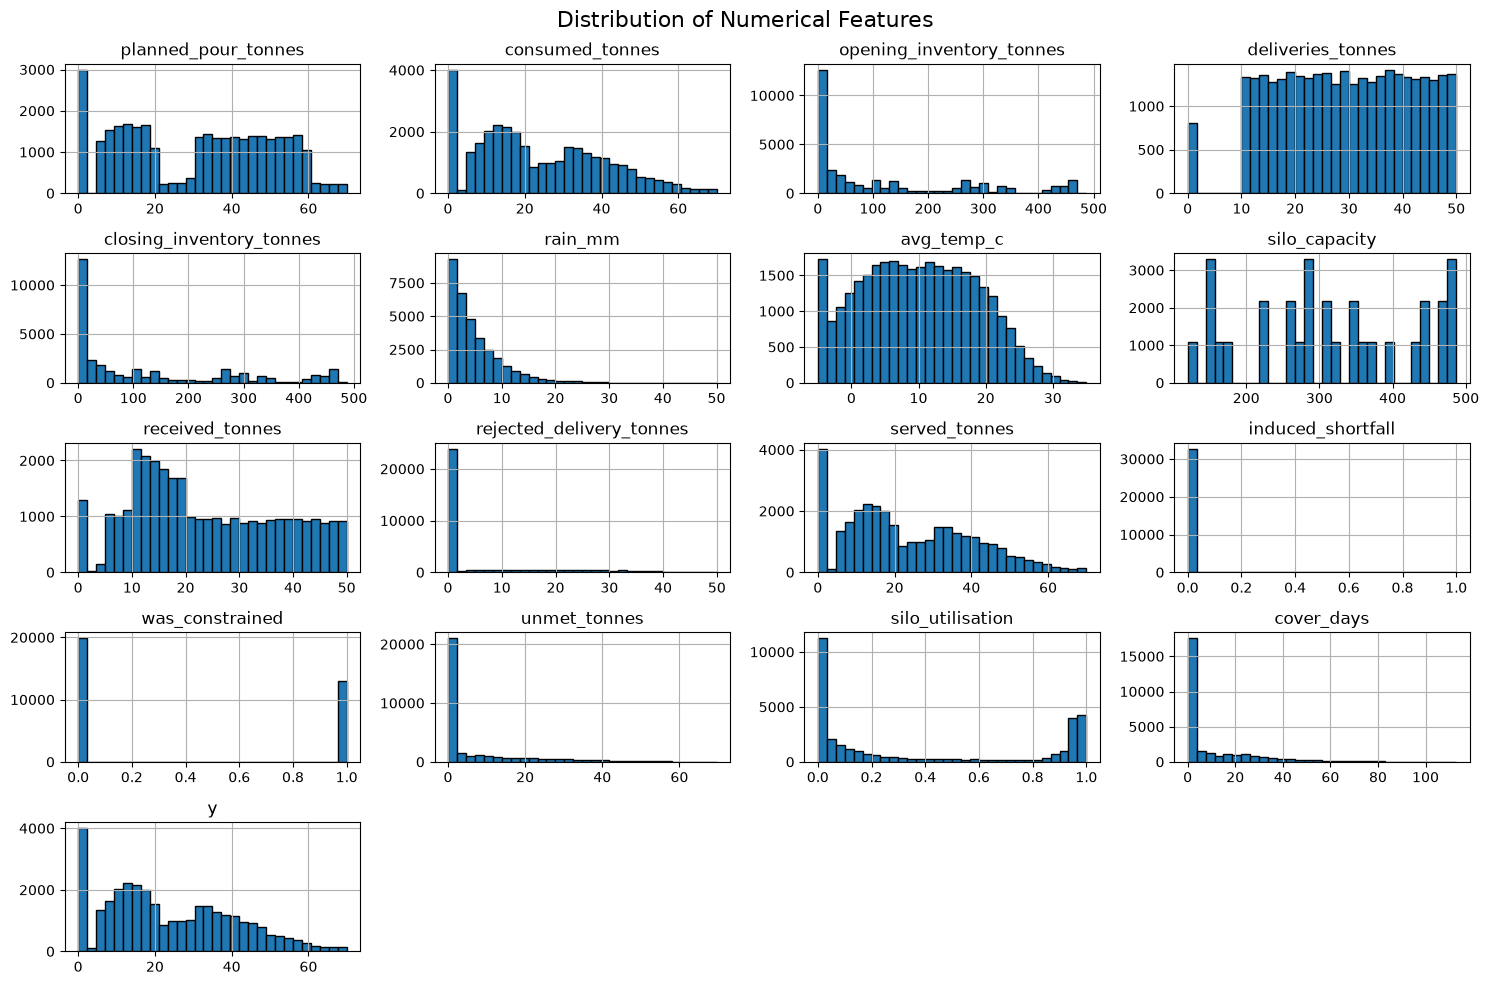

In [11]:
# ==========================================
# Distribution of Numerical Features
# ==========================================

numerical_cols = panel.select_dtypes(include=["number"]).columns

panel[numerical_cols].hist(
    figsize=(15, 10),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

## Target Variable Analysis

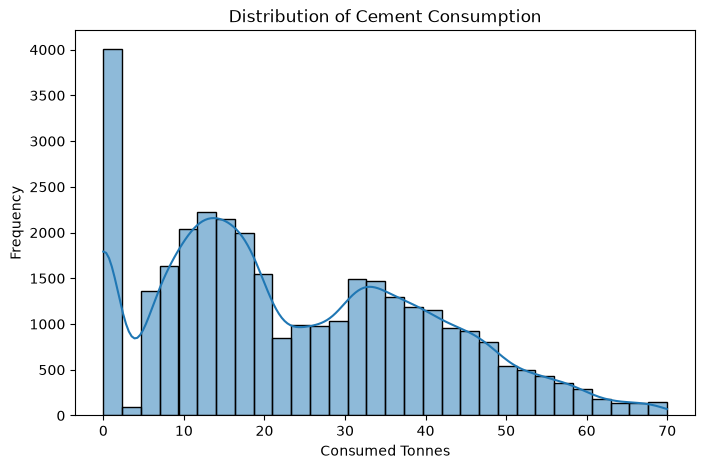

In [12]:
# ==========================================
# Distribution of Cement Consumption
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(
    panel["consumed_tonnes"],
    bins=30,
    kde=True
)

plt.title("Distribution of Cement Consumption")
plt.xlabel("Consumed Tonnes")
plt.ylabel("Frequency")

plt.show()

The target variable was analysed to understand the overall pattern of daily cement demand. Most observations fall within the low to moderate consumption range, while high-consumption days occur less frequently.

## Time Series Trend

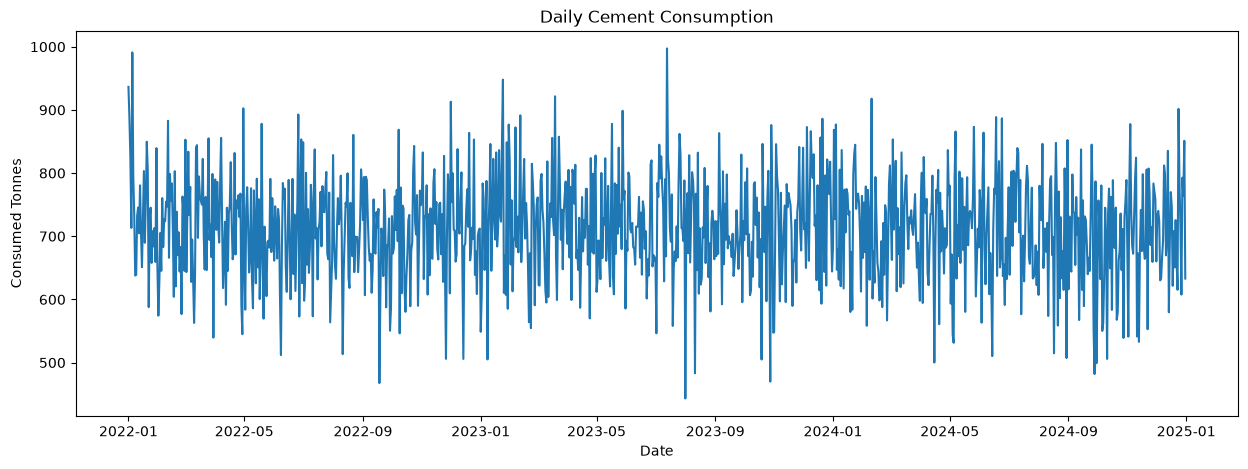

In [13]:
# ==========================================
# Daily Cement Consumption
# ==========================================

daily = (
    panel
    .groupby("date")["consumed_tonnes"]
    .sum()
)

plt.figure(figsize=(15,5))

plt.plot(daily.index, daily.values)

plt.title("Daily Cement Consumption")
plt.xlabel("Date")
plt.ylabel("Consumed Tonnes")

plt.show()

Daily cement consumption was plotted to identify temporal patterns and fluctuations. The results show substantial day-to-day variation but no obvious long-term increasing or decreasing trend.

## Monthly Trend

C:\Users\Olami\AppData\Local\Temp\ipykernel_19016\3060248904.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["consumed_tonnes"]


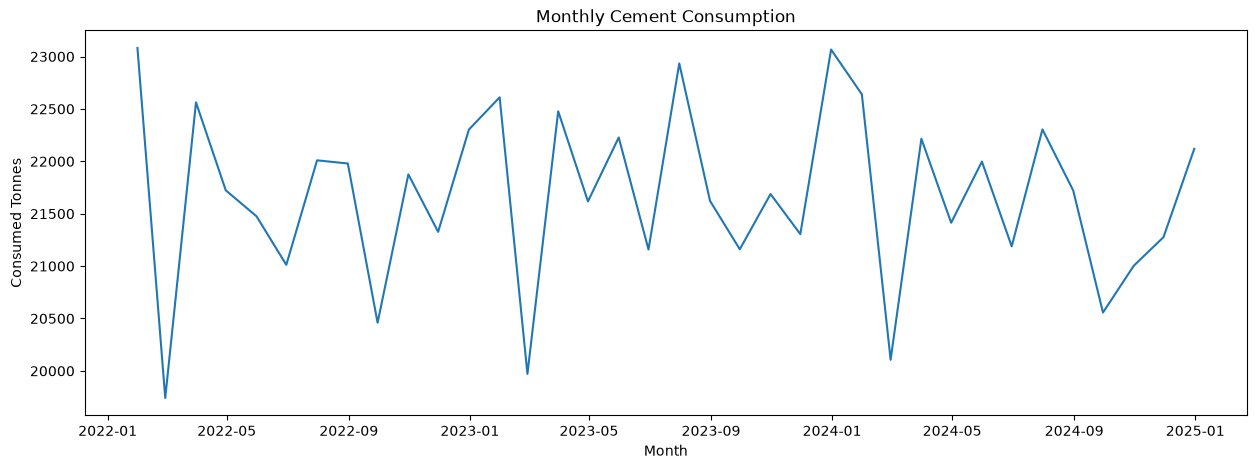

In [14]:
# ==========================================
# Monthly Cement Consumption
# ==========================================

monthly = (
    panel
    .set_index("date")
    .resample("M")["consumed_tonnes"]
    .sum()
)

plt.figure(figsize=(15,5))

plt.plot(monthly.index, monthly.values)

plt.title("Monthly Cement Consumption")

plt.xlabel("Month")
plt.ylabel("Consumed Tonnes")

plt.show()

Monthly consumption was analysed to smooth daily fluctuations and examine longer-term demand. The results indicate relatively stable monthly demand with moderate variations across the study period.

## Consumption by Region

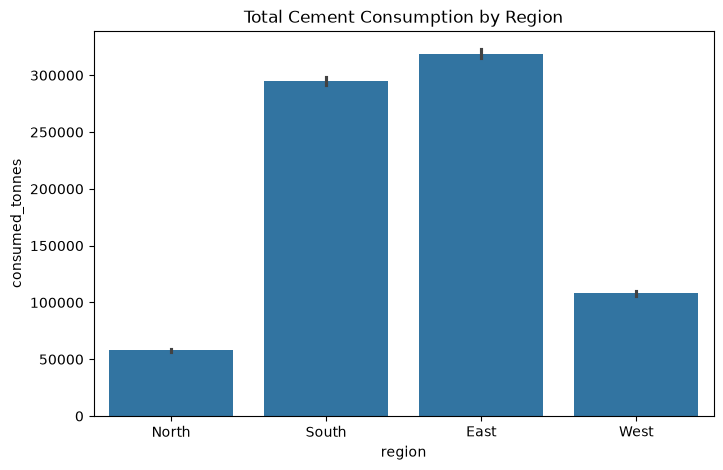

In [15]:
# ==========================================
# Cement Consumption by Region
# ==========================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=panel,
    x="region",
    y="consumed_tonnes",
    estimator="sum"
)

plt.title("Total Cement Consumption by Region")

plt.show()

Regional consumption was compared to identify geographical differences in demand. The East region recorded the highest total cement consumption, followed by the South, while the North and West contributed considerably lower demand.

## Consumption by Cement Type

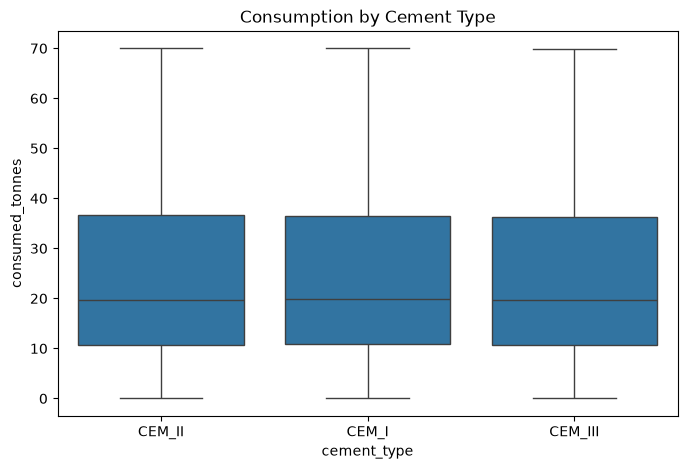

In [16]:
# ==========================================
# Cement Type Analysis
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=panel,
    x="cement_type",
    y="consumed_tonnes"
)

plt.title("Consumption by Cement Type")

plt.show()

Cement consumption was compared across the three cement types to identify differences in usage. The distributions are broadly similar, suggesting that demand patterns do not differ substantially between cement types.

## Weather Analysis

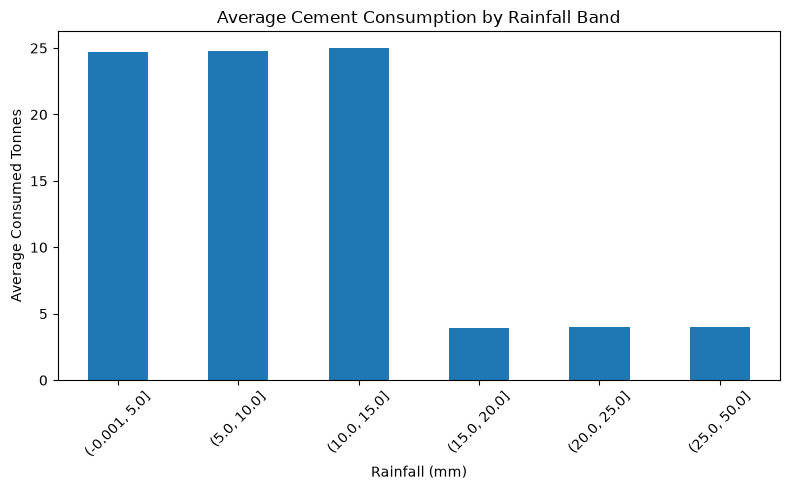

In [26]:
# Create rainfall categories

panel["rainfall_band"] = pd.cut(
    panel["rain_mm"],
    bins=[0,5,10,15,20,25,50],
    include_lowest=True
)

rainfall_summary = (
    panel.groupby("rainfall_band", observed=False)["consumed_tonnes"]
    .mean()
)

plt.figure(figsize=(8,5))

rainfall_summary.plot(kind="bar")

plt.title("Average Cement Consumption by Rainfall Band")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Average Consumed Tonnes")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The relationship between rainfall and cement consumption was explored to assess the potential influence of weather. The scatter plot indicates a weak negative relationship, with higher rainfall generally associated with slightly lower cement consumption.

## Correlation Analysis

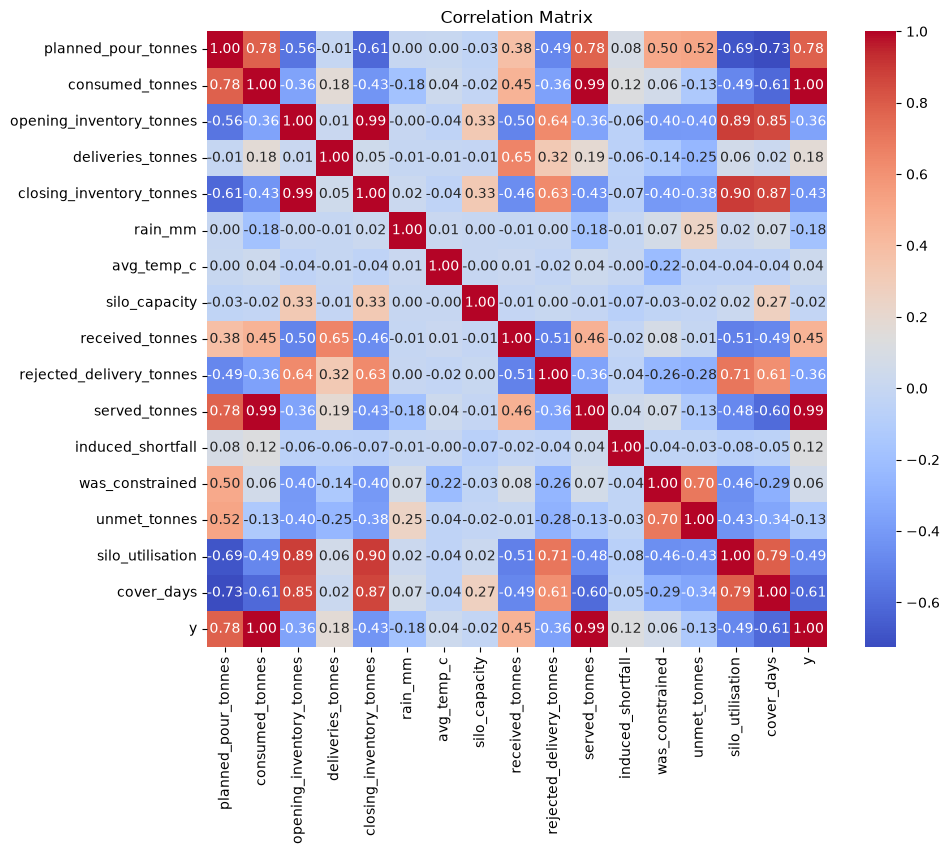

In [18]:
# ==========================================
# Correlation Matrix
# ==========================================

plt.figure(figsize=(10,8))

sns.heatmap(
    panel.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

Correlation analysis was performed to identify relationships between the numerical variables. Planned pour tonnage shows the strongest positive correlation with cement consumption (0.78), while rainfall exhibits a weak negative correlation (-0.18), indicating that operational factors are stronger predictors of demand than weather.

## Average Cement Consumption by Site

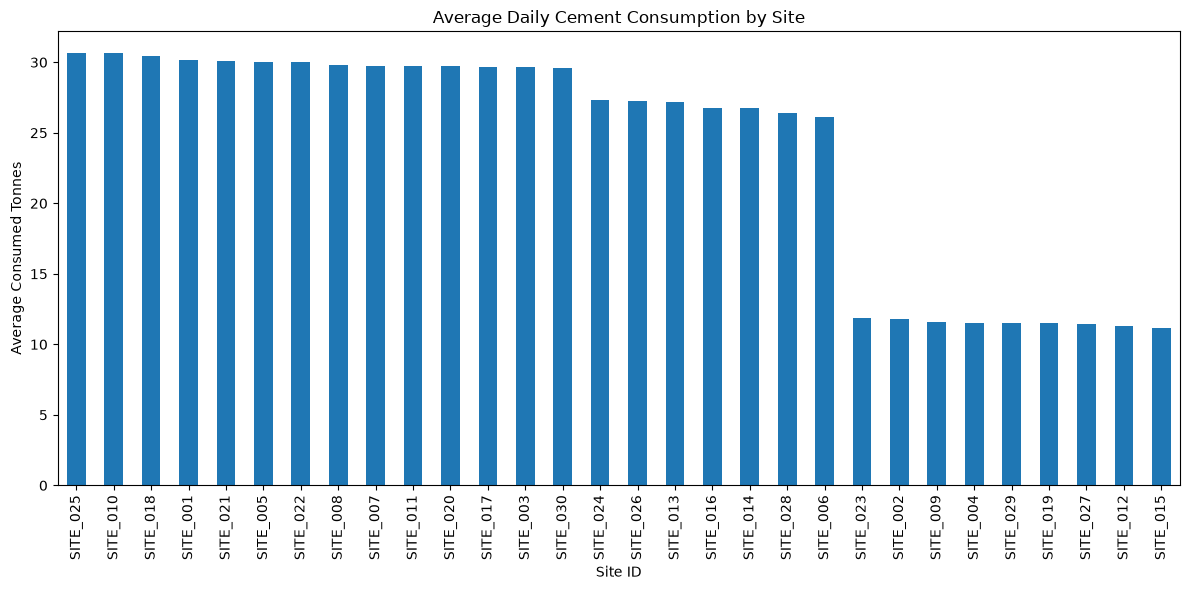

In [20]:
# ==========================================
# Average Cement Consumption by Site
# ==========================================

site_demand = (
    panel.groupby("site_id")["consumed_tonnes"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

site_demand.plot(kind="bar")

plt.title("Average Daily Cement Consumption by Site")
plt.xlabel("Site ID")
plt.ylabel("Average Consumed Tonnes")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Average daily cement consumption varies considerably across sites, with some sites recording around 30 tonnes per day while others average close to 11 tonnes. This indicates that site-level differences are important when forecasting cement demand.

## Monthly Seasonality Analysis

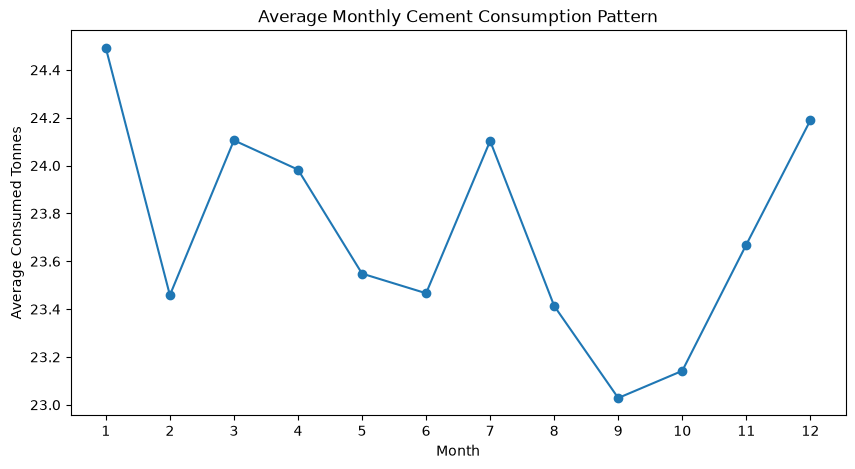

In [21]:
# ==========================================
# Monthly Seasonality Analysis
# ==========================================

panel["month"] = panel["date"].dt.month

monthly_seasonality = (
    panel.groupby("month")["consumed_tonnes"]
    .mean()
)

plt.figure(figsize=(10, 5))

monthly_seasonality.plot(marker="o")

plt.title("Average Monthly Cement Consumption Pattern")
plt.xlabel("Month")
plt.ylabel("Average Consumed Tonnes")

plt.xticks(range(1, 13))

plt.show()

Monthly consumption varies slightly throughout the year, with the highest average demand in January and the lowest in September. Overall, the variation is relatively small, suggesting no strong seasonal pattern.

##### Received vs Rejected Deliveries

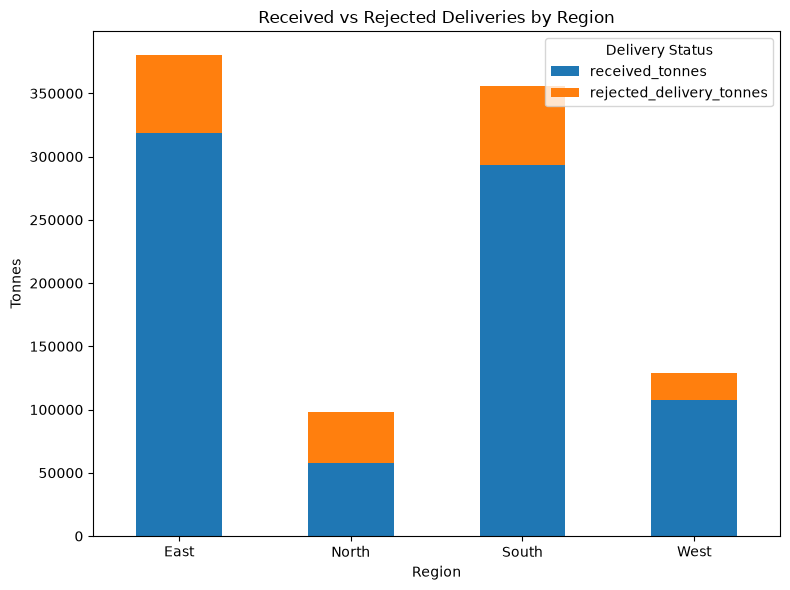

In [22]:
# Received vs Rejected Deliveries by Region

delivery_summary = panel.groupby("region")[
    ["received_tonnes", "rejected_delivery_tonnes"]
].sum()

delivery_summary.plot(
    kind="bar",
    stacked=True,
    figsize=(8,6)
)

plt.title("Received vs Rejected Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Tonnes")
plt.legend(title="Delivery Status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Served vs Unmet Tonnes

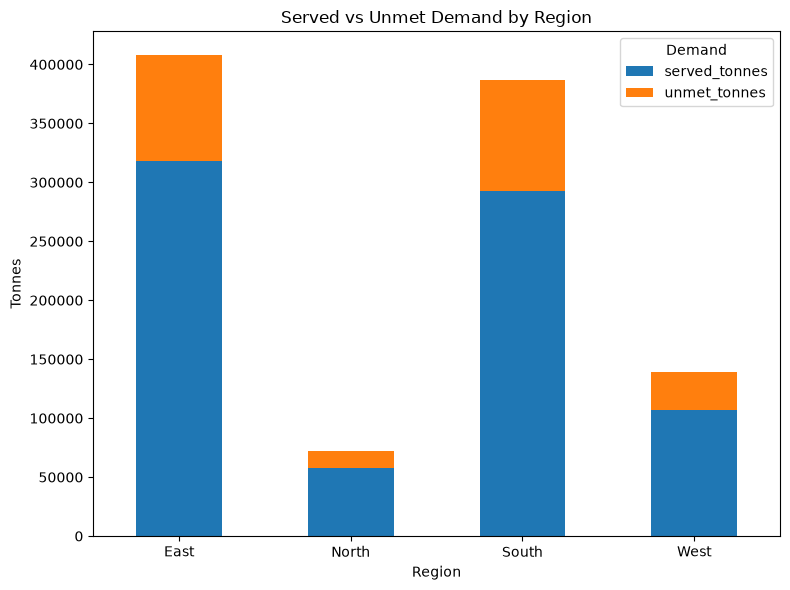

In [23]:
# Served vs Unmet Demand by Region

service_summary = panel.groupby("region")[
    ["served_tonnes", "unmet_tonnes"]
].sum()

service_summary.plot(
    kind="bar",
    stacked=True,
    figsize=(8,6)
)

plt.title("Served vs Unmet Demand by Region")
plt.xlabel("Region")
plt.ylabel("Tonnes")
plt.legend(title="Demand")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Was Constrained

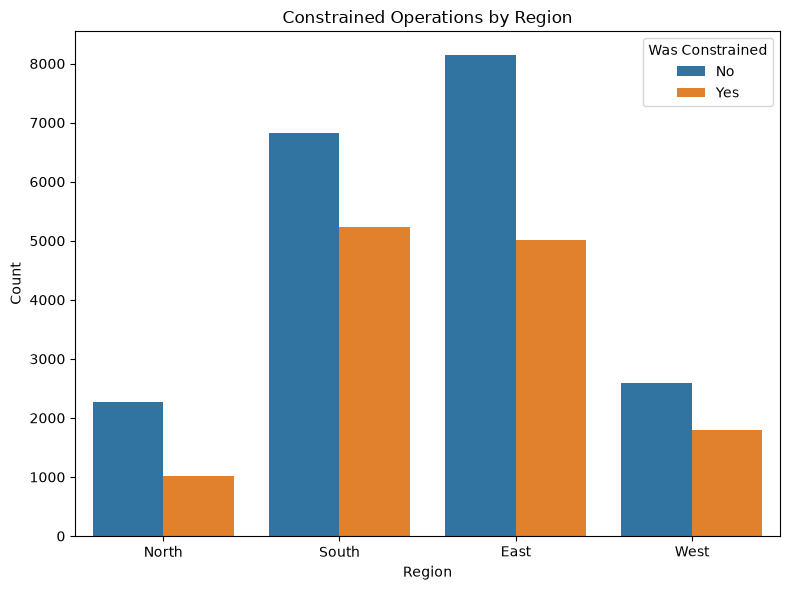

In [25]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=panel,
    x="region",
    hue="was_constrained")

plt.title("Constrained Operations by Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.legend(title="Was Constrained", labels=["No","Yes"])

plt.tight_layout()
plt.show()

### SILO UTILISATION

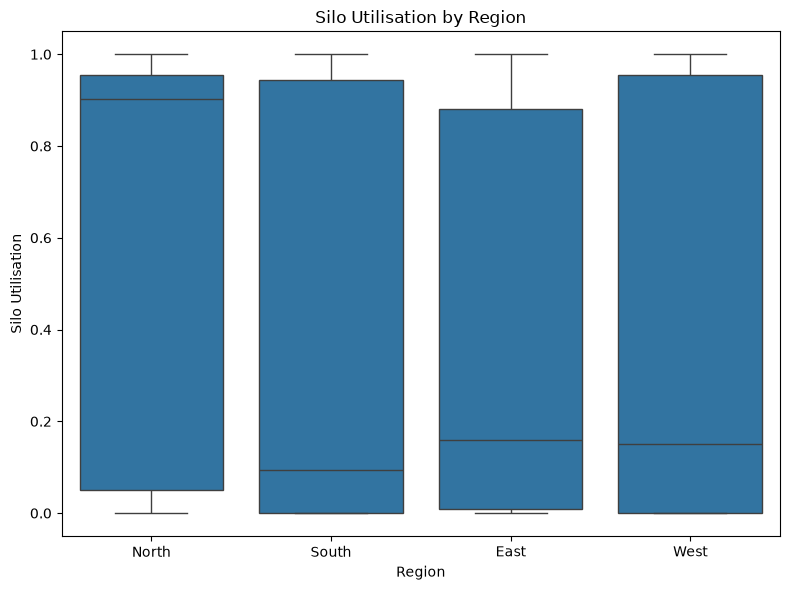

In [27]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=panel,
    x="region",
    y="silo_utilisation"
)

plt.title("Silo Utilisation by Region")
plt.xlabel("Region")
plt.ylabel("Silo Utilisation")

plt.tight_layout()
plt.show()

#### INVENTORY COVERAGE 

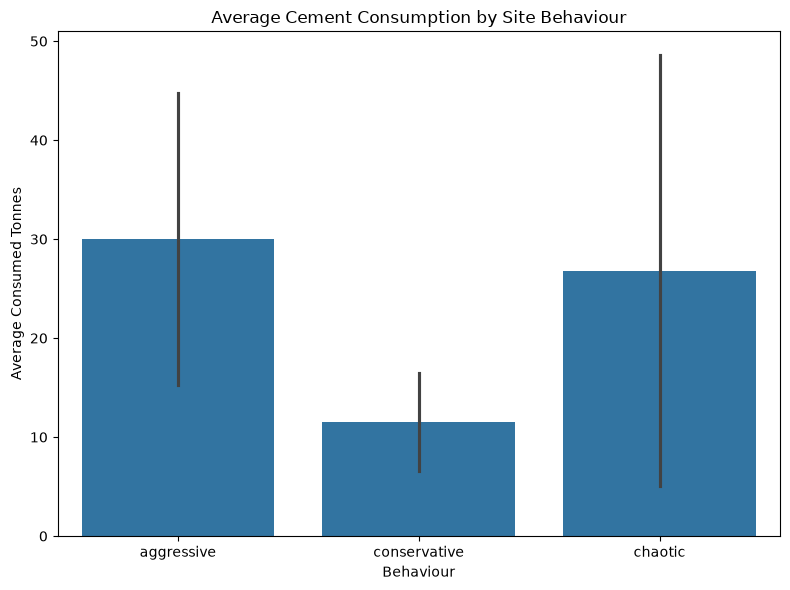

In [29]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=panel,
    x="behavior",
    y="consumed_tonnes",
    estimator="mean",
    errorbar="sd")

plt.title("Average Cement Consumption by Site Behaviour")
plt.xlabel("Behaviour")
plt.ylabel("Average Consumed Tonnes")

plt.tight_layout()
plt.show()